# Motorbike Theft Analysis in Spain

**Goal:** quantify and characterize reported motorbike thefts in Spain to support a product decision on a recovery-oriented feature.

**Business questions:**
- Are there less stolen motorbikes now than 5 years ago?
- Is there any brand that gets stolen more?
- Do we know if expensive bikes are stolen more often?
- What about the location of the stolen motorbikes?

**TL;DR**
- Theft volume varies by year; macro effects (e.g., 2020) matter for interpretation.
- Thefts show time patterns (month/weekday) and strong geographic concentration by province.
- Vehicle age at theft is skewed; median is more informative than mean.
- Recommendation: if building a recovery feature, start with a region-focused rollout and measure impact.

In [2]:
import pandas as pd

from src.data_loading import load_raw_dgt_csv, load_province_population
from src.data_processing import preprocess_motorbike_thefts, transform_province_names
from src.analysis import thefts_by_year, thefts_by_month, thefts_by_weekday, summary_by_dimension
from src.visualization import bar_plot, plot_total_share_and_antiquity, plot_count_and_growth_by_year, plot_year_comparison_and_growth, plot_antiquity_histogram, plot_top_rates

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 120)


### 1. Data loading

Dataset: official public records (DGT). This analysis focuses on reported incidents; underreporting may exist.


In [3]:
# Load and preprocess data
RAW_PATH = "data/raw/stolen_motorbikes_dgt(in).csv"
df_raw = load_raw_dgt_csv(RAW_PATH)

df_raw.head()


,registration_date,stolen_date,brand,model,province
0,2005-06-23,2017-01-01,HONDA,SH125,M
1,2015-11-02,2017-01-01,HONDA,ANC125,B
2,2011-05-06,2017-01-01,YAMAHA,YP125R,SS
3,1995-05-12,2017-01-01,HONDA,NH 90,GR
4,2011-02-09,2017-01-01,S.Y.M,GTS 125 EVO,CE


### 2. Preprocessing

To keep the code reusable and readable, we should map raw columns to a small set of standard names, but current names are already correct.

I parse dates, remove unusable rows (missing theft date), and create a few analysis-friendly features:
- stolen_year, stolen_month, stolen_weekday
- years_to_stole (proxy for vehicle age at theft)
- brand_model


In [4]:
df = preprocess_motorbike_thefts(df_raw)
df.head()

Stolen motorbikes from 2017-01-01 00:00:00 to 2022-11-30 00:00:00.


,registration_date,stolen_date,brand,model,province,stolen_year,stolen_month,stolen_weekday,stolen_weekday_name,years_to_stole,brand_model
0,2005-06-23,2017-01-01,HONDA,SH125,M,2017,1,6,Sunday,11.526352,HONDA - SH125
1,2015-11-02,2017-01-01,HONDA,ANC125,B,2017,1,6,Sunday,1.166324,HONDA - ANC125
2,2011-05-06,2017-01-01,YAMAHA,YP125R,SS,2017,1,6,Sunday,5.659138,YAMAHA - YP125R
3,1995-05-12,2017-01-01,HONDA,NH 90,GR,2017,1,6,Sunday,21.642710,HONDA - NH 90
4,2011-02-09,2017-01-01,S.Y.M,GTS 125 EVO,CE,2017,1,6,Sunday,5.894593,S.Y.M - GTS 125 EVO


In [5]:
df.isna().mean().sort_values(ascending=False).head(15)

province               0.002929
model                  0.000618
registration_date      0.000000
stolen_date            0.000000
brand                  0.000000
stolen_year            0.000000
stolen_month           0.000000
stolen_weekday         0.000000
stolen_weekday_name    0.000000
years_to_stole         0.000000
brand_model            0.000000
dtype: float64

### 3. Data sanity checks

These checks are intentionally lightweight: enough to validate the dataset without over-engineering.

In [6]:
print("Rows:", len(df))
print("Date range:", df["stolen_date"].min(), "→", df["stolen_date"].max())
df[["stolen_year", "stolen_month"]].info()

Rows: 37216
Date range: 2017-01-01 00:00:00 → 2022-11-30 00:00:00
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37216 entries, 0 to 37215
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   stolen_year   37216 non-null  int32
 1   stolen_month  37216 non-null  int32
dtypes: int32(2)
memory usage: 290.9 KB


In [7]:
df["years_to_stole"].describe()

count    37216.000000
mean         9.200735
std          7.835754
min          0.002738
25%          3.205339
50%          7.630390
75%         12.846680
max         76.610541
Name: years_to_stole, dtype: float64

### 4. Seasonality (year, month, weekday)

Purpose: detect temporal patterns that can influence product strategy (alerts, partnerships, etc).

,stolen_year,count,growth_pct
0,2017,7281,NaN
1,2018,7548,3.667079
2,2019,7179,-4.888712
3,2020,4895,-31.815016
4,2021,4405,-10.010215
5,2022,5908,34.120318


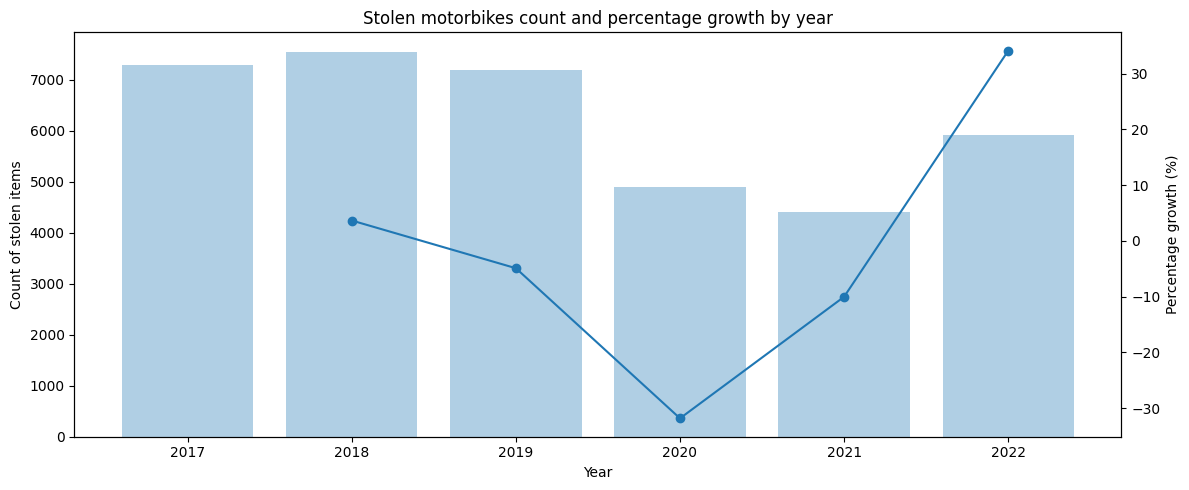

In [8]:
df_year = thefts_by_year(df)
display(df_year)
plot_count_and_growth_by_year(df_year)

**Interpretation:** year-to-year changes provide context for the rest of the analysis. Large shifts (e.g., 2020) should be treated as macro-effects rather than product-driven patterns.

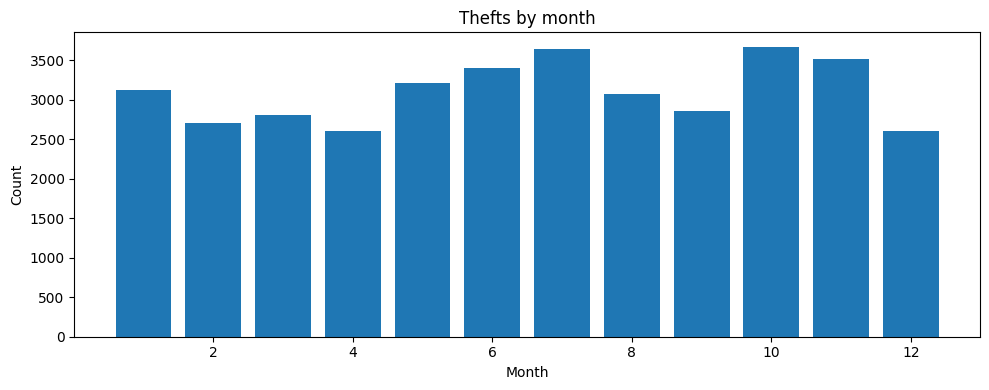

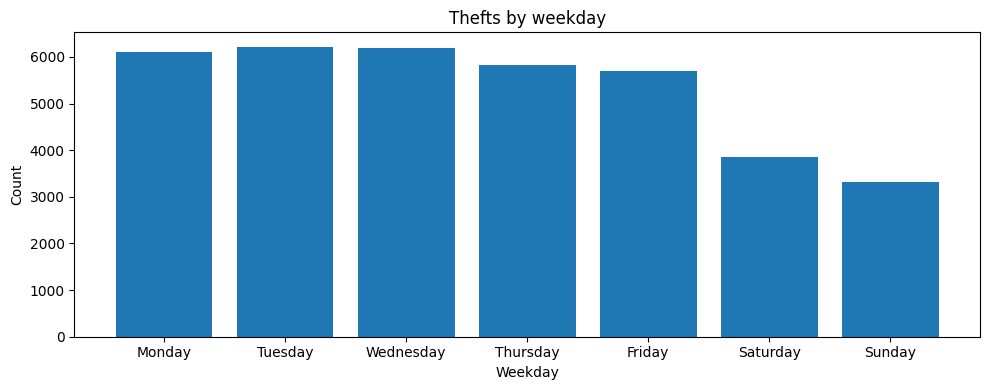

In [9]:
df_month = thefts_by_month(df)
bar_plot(df_month["stolen_month"], df_month["count"], "Thefts by month", xlabel="Month", ylabel="Count")

df_weekday = thefts_by_weekday(df)
bar_plot(df_weekday["stolen_weekday_name"], df_weekday["count"], "Thefts by weekday", xlabel="Weekday", ylabel="Count")


**Interpretation:** month/weekday patterns suggest theft exposure is not uniform across time. This supports timing-aware product interventions (e.g., awareness nudges, insurance/parking partnerships, or region/time targeting).


### 5. Antiquity and theft time

Purpose: estimate how long after registration vehicles are typically stolen. This is a proxy for theft risk over the lifecycle and may inform targeting (e.g., newer vs older vehicles).

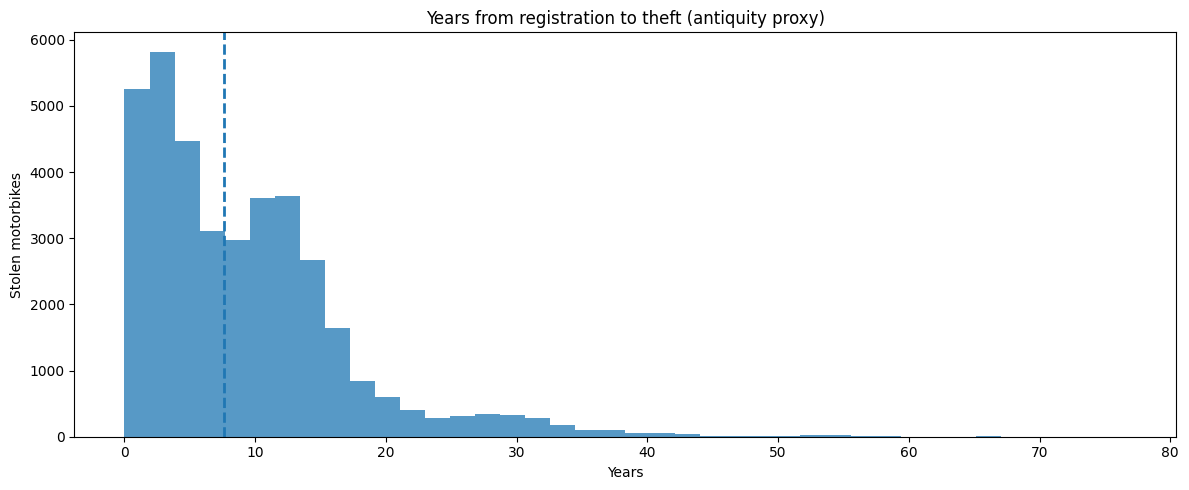

count    37216.000000
mean         9.200735
std          7.835754
min          0.002738
25%          3.205339
50%          7.630390
75%         12.846680
max         76.610541
Name: years_to_stole, dtype: float64

In [10]:
plot_antiquity_histogram(df, reference="median")
df["years_to_stole"].describe()

**Interpretation:** the distribution is skewed (long tail), so median is a more robust summary than mean. This can help decide whether to tailor the feature for recently registered vehicles or a broader base.

### 6. Geographic concentration (provinces)

Purpose: identify where the problem concentrates to prioritize a phased rollout and maximize impact early.

In [11]:
pr = load_province_population("data/raw/province_population.csv")[["Provincias", "Periodo", "Total"]]
pr = transform_province_names(pr, "Provincias").rename(columns={"Total": "num_hab"})
pr["num_hab"] = pr["num_hab"].str.replace(".", "").astype(int)

In [12]:
prov = summary_by_dimension(
    df,
    dimension="province",
    years_for_growth=(2021, 2022),
    end_date_mmdd="11-30",
    min_count_growth=10,
).reset_index(drop=True)

prov_pop = pd.merge(prov, pr[pr["Periodo"]==2022], left_on=["province"], right_on=["province_code"], how="left").drop(columns=["Periodo", "province_code", "Provincias"])
prov_pop["stolen_per_100k"] = (prov_pop["stolen_total"] / prov_pop["num_hab"]) * 100000

prov_pop.head(10)

,province,stolen_total,avg_years_to_stole,pct_of_total,stolen_2021,stolen_2022,growth_pct,is_growth_reliable,num_hab,stolen_per_100k
0,B,16228,8.201788,43.732988,1399,2182,55.968549,True,5727615.0,283.329099
1,M,6498,7.784079,17.511521,962,1235,28.378378,True,6750336.0,96.261875
2,SE,2164,10.250250,5.831784,209,281,34.449761,True,1948393.0,111.065889
3,V,1318,12.959652,3.551890,142,248,74.647887,True,2605757.0,50.580311
4,MA,1256,10.257458,3.384806,141,219,55.319149,True,1717504.0,73.129378
5,IB,1243,8.951056,3.349772,116,286,146.551724,True,1176659.0,105.638082
6,CA,898,9.091390,2.420029,101,163,61.386139,True,1246781.0,72.025480
7,A,693,12.004496,1.867572,69,133,92.753623,True,1901594.0,36.443110
8,GI,626,11.254780,1.687013,62,109,75.806452,True,793478.0,78.893177
9,TF,505,9.213275,1.360929,45,70,55.555556,True,1048306.0,48.172957


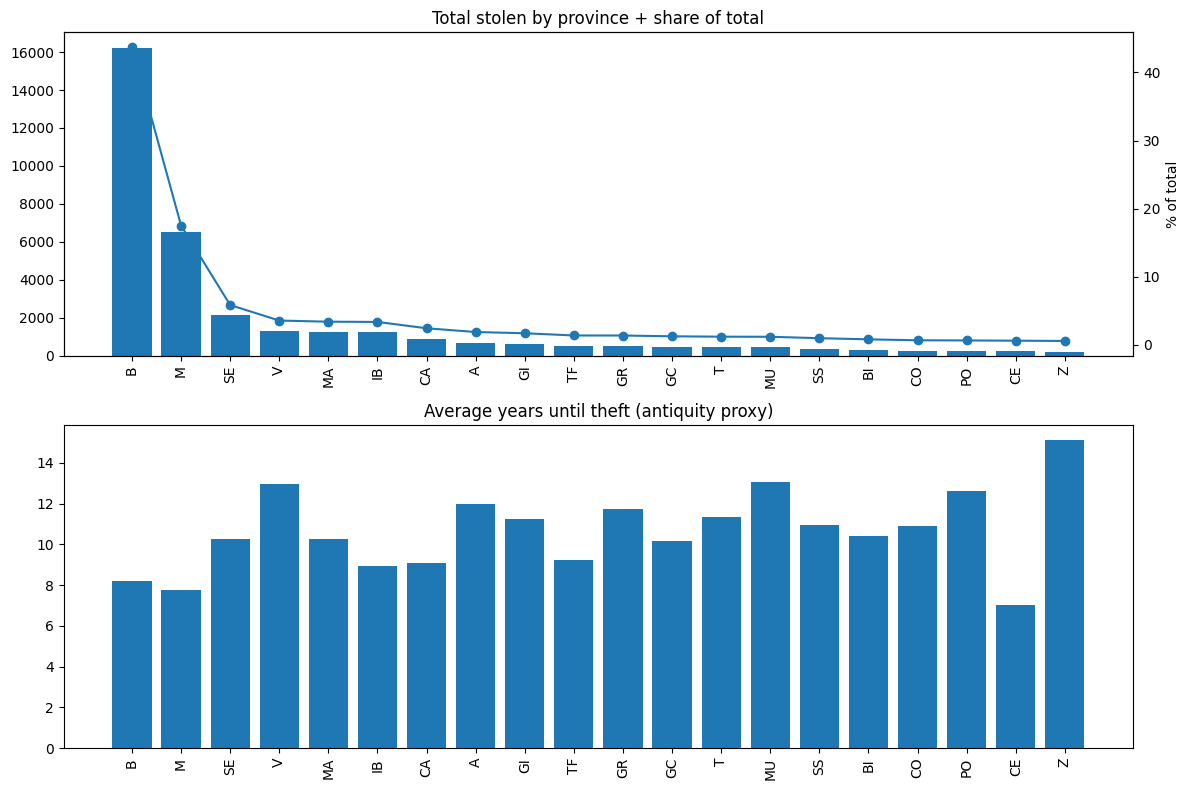

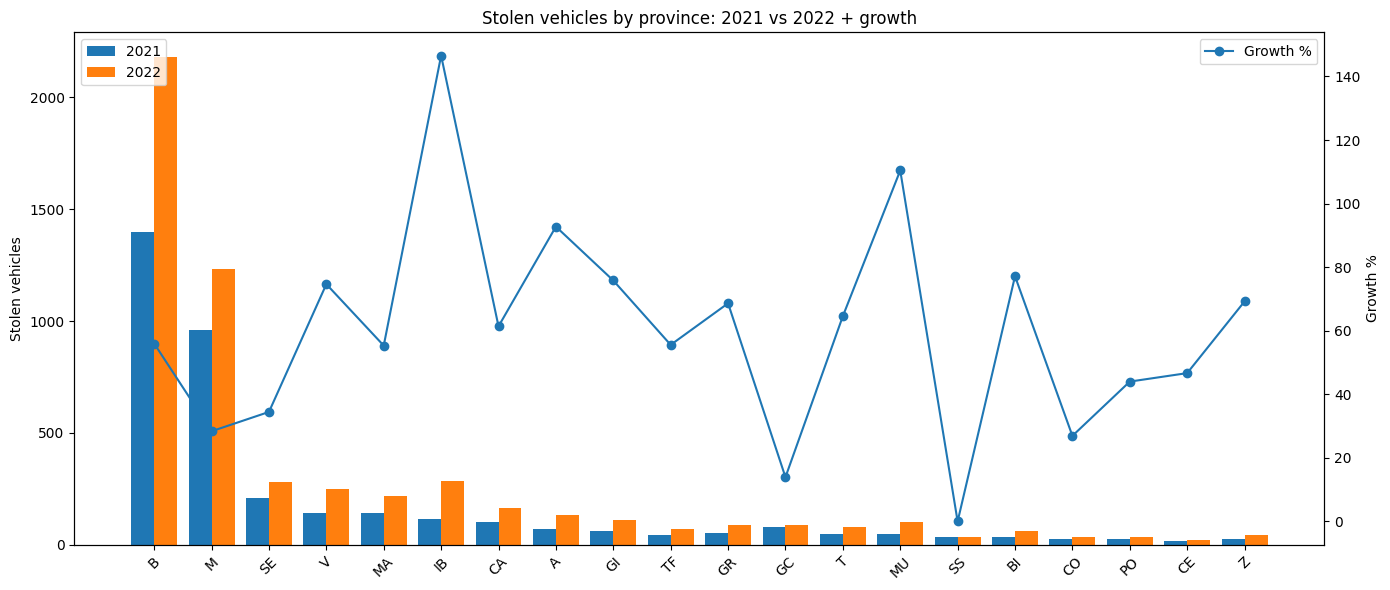

In [13]:
top_prov = prov.head(20)
plot_total_share_and_antiquity(top_prov, dimension="province")
plot_year_comparison_and_growth(top_prov, dimension="province", year1=2021, year2=2022, reliable_only=True)

**Interpretation:** incidents are concentrated: a limited set of provinces account for a large share of thefts. A region-first rollout is likely more efficient than a nationwide launch.

/Users/josep/Documents/projects/spain-motorbike-theft-analysis/src/visualization.py:116: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(data[dimension], rotation=90)


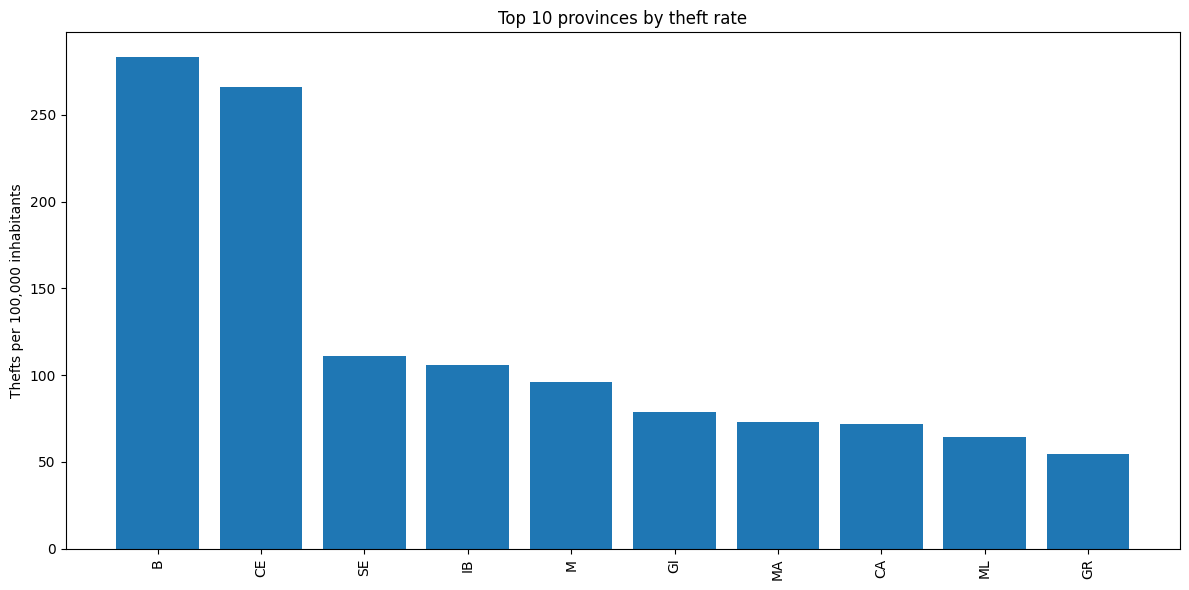

In [14]:
plot_top_rates(prov_pop, "province", "stolen_per_100k", 10)

**Interpretation:** counts identify where most thefts happen, but rates (per 100k inhabitants) adjust for province size. For prioritization, rates help spot disproportionately affected areas that may be masked by population volume.

Note: population is a proxy for exposure; the best denominator would be registered motorbikes by province (vehicle parc), if available.

### 6. Vehicle patterns (brands)

Purpose: understand whether thefts correlate with a small set of popular brands (proxy: prevalence + desirability).

In [15]:
brands = summary_by_dimension(df, dimension="brand", years_for_growth=(2021, 2022), end_date_mmdd="11-30", min_count_growth=20)
brands.head(15)

,brand,stolen_total,avg_years_to_stole,pct_of_total,stolen_2021,stolen_2022,growth_pct,is_growth_reliable
66,HONDA,14113,8.499924,37.921862,1172,1817,55.034130,True
209,YAMAHA,5077,9.570070,13.641982,584,882,51.027397,True
101,KYMCO,4074,6.437643,10.946905,552,750,35.869565,True
142,PIAGGIO,2485,9.774371,6.677236,314,360,14.649682,True
179,SUZUKI,1883,11.426623,5.059652,183,300,63.934426,True
158,S.Y.M,1053,4.660186,2.829428,114,0,-100.000000,True
94,KAWASAKI,1016,7.326912,2.730009,118,160,35.593220,True
200,VESPA,840,32.015055,2.257094,79,103,30.379747,True
140,PEUGEOT,821,5.927130,2.206040,122,194,59.016393,True
100,KTM,697,8.531811,1.872850,83,144,73.493976,True


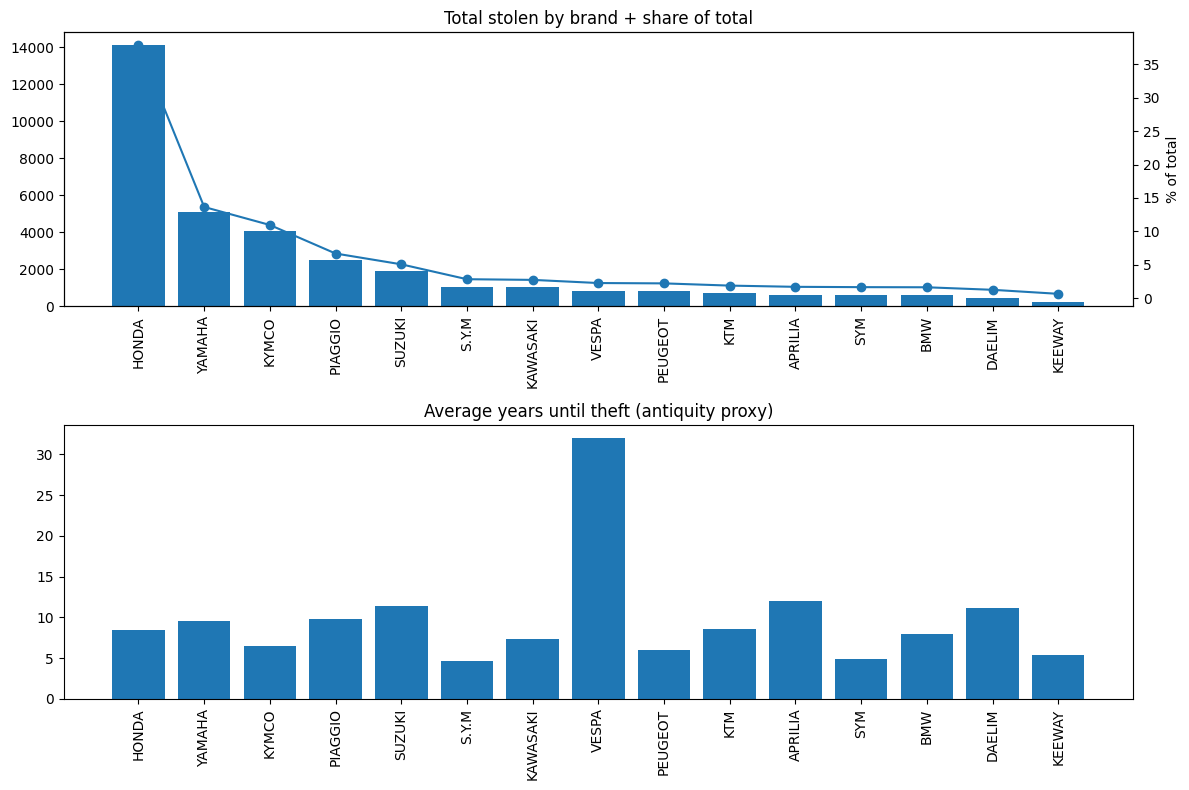

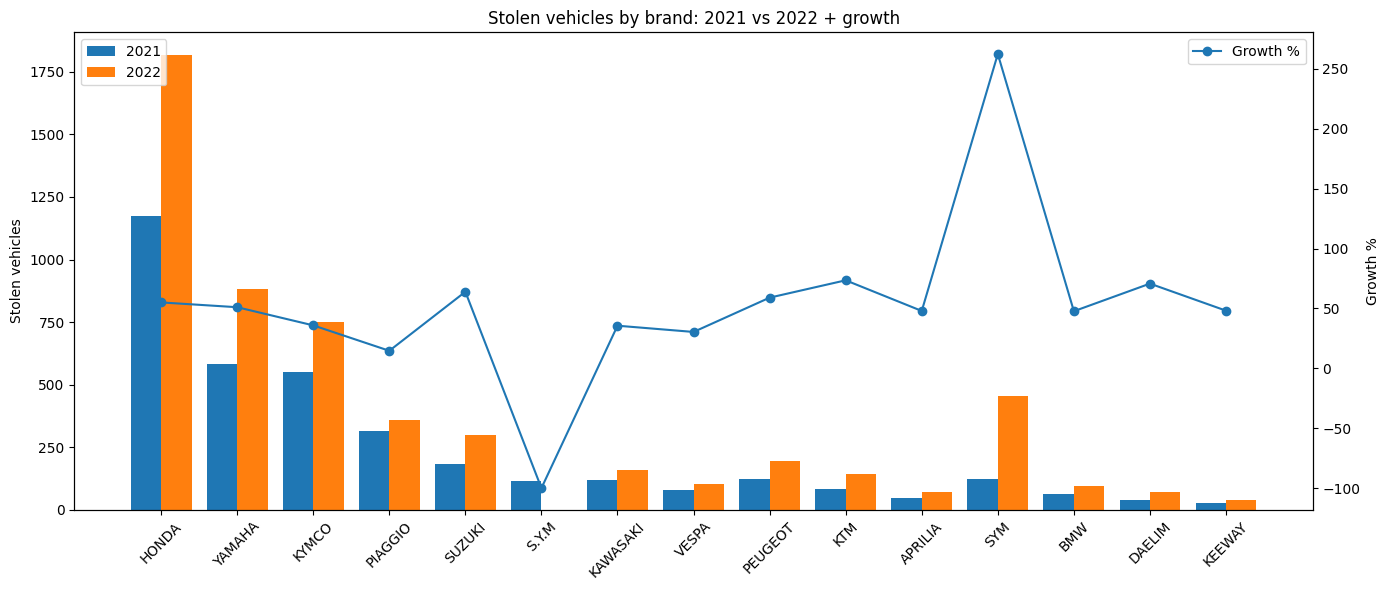

In [16]:
top_brands = brands.head(15)
plot_total_share_and_antiquity(top_brands, dimension="brand")
plot_year_comparison_and_growth(top_brands, dimension="brand", year1=2021, year2=2022, reliable_only=True)

### 7. Vehicle patterns (models)

Models can be noisy due to naming inconsistencies. I focus on the top models by volume to avoid over-interpreting sparse categories.

In [17]:
models = summary_by_dimension(df, dimension="model", years_for_growth=(2021, 2022), end_date_mmdd="11-30", min_count_growth=20)
models.head(15)

,model,stolen_total,avg_years_to_stole,pct_of_total,stolen_2021,stolen_2022,growth_pct,is_growth_reliable
2487,SH125AD,3123,3.087147,8.396741,181,330,82.320442,True
2482,SH125,2129,11.646618,5.724195,196,354,80.612245,True
2489,SH125D,1817,3.443418,4.885328,38,78,105.263158,True
294,AGILITY CITY 125,824,4.768874,2.215471,127,153,20.472441,True
3197,WW125EX2,635,5.489688,1.707311,92,101,9.782609,True
2454,SES125,594,12.918194,1.597075,42,65,54.761905,True
2701,SUPER DINK 125,554,5.693860,1.489528,74,104,40.540541,True
2493,SH150,542,14.266471,1.457263,42,75,78.571429,True
2897,TWEET,528,3.378990,1.419622,84,140,66.666667,True
3398,XP500,485,7.301453,1.304009,52,72,38.461538,True


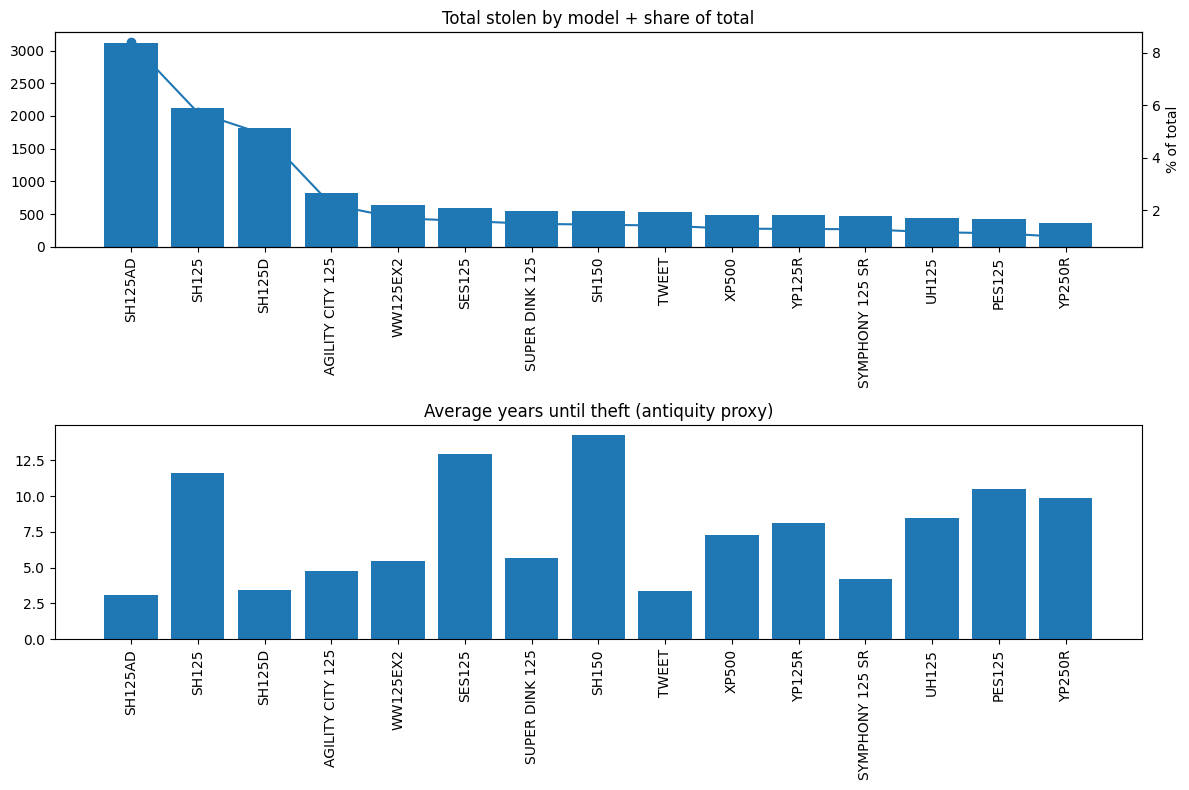

In [18]:
top_models = models.head(15)
plot_total_share_and_antiquity(top_models, dimension="model")

**Interpretation:** brand/model distributions typically reflect a mix of market share and theft attractiveness. For product design, this can guide default filters, alerts, or prioritization logic.

### Method note (brands/models)
Theft counts by brand/model are not directly comparable without an exposure denominator (e.g., number of registered/active vehicles by brand/model).  
In this project, brand/model results should be interpreted as **volume signals** (popularity + desirability), not as theft risk rankings.  
If vehicle parc data were available, the correct metric would be: thefts per 10,000 registered vehicles for each brand/model.

### 8. Conclusions

**Key insights**
- Theft incidence shows non-uniform temporal patterns (seasonality and weekday effects).
- Incidents are geographically concentrated: a limited set of provinces represent a meaningful share.
- Brand/model patterns are consistent with popularity + desirability effects; interpretation should avoid sparse categories.

**Product implication**
- A recovery-oriented feature is more likely to succeed with a phased, region-first rollout (start where incidents concentrate), paired with measurement of adoption and recovery outcomes.

**Next steps (if this were production)**
- Normalize brand/model strings (dedup + mapping) to reduce category noise.
- Add population / vehicle ownership denominators to compute theft rates (not just counts).
- Evaluate impact with an experiment design (targeted launch in high-incidence regions vs control).
